# Notebook 01 — Simulation du modèle de Merton (Expérience E1)

**PFE MMF ING3 — CY Tech, 2025-2026**  
Auteurs : Corentin Stephan, Hugo Landron  
Encadrants : Y. Aktar, I. Kortchemski

---

## Objectif

Ce notebook implémente l'**expérience E1** du plan d'expériences : simulation de trajectoires du modèle de Merton et illustration des sauts.

### Rappel du modèle

Sous la mesure réelle $\mathbb{P}$, la dynamique du sous-jacent est (Merton, 1976) :

$$\frac{dS_t}{S_{t^-}} = (\mu - \lambda \bar{k})\,dt + \sigma\,dW_t + d\left(\sum_{i=1}^{N_t}(Y_i - 1)\right)$$

avec :
- $\mu$ : rendement instantané espéré
- $\sigma > 0$ : volatilité diffusive
- $N_t$ : processus de Poisson d'intensité $\lambda$
- $\ln Y_i \sim \mathcal{N}(\mu_J, \delta^2)$ : amplitudes des sauts (log-normales)
- $\bar{k} = \mathbb{E}[Y-1] = e^{\mu_J + \delta^2/2} - 1$ : saut moyen (compensateur)

### Sorties
- 10 trajectoires de prix avec mise en évidence des sauts
- Histogramme des log-rendements (comparaison avec une gaussienne)
- Statistiques descriptives : excès de kurtosis, asymétrie

In [1]:
import sys
import os

# Ajout du repertoire src/ au path Python
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math

from merton_calib.simulation import simulate_merton_paths, log_returns

# Fonctions statistiques (remplacement scipy.stats, non disponible)
def _norm_cdf_nb(x):
    return 0.5 * (1.0 + math.erf(float(x) / math.sqrt(2.0)))

def excess_kurtosis(arr):
    """Kurtosis excentaire (Fisher) = E[(X-mu)^4]/sigma^4 - 3."""
    mu = arr.mean(); s = arr.std()
    return float(np.mean(((arr - mu) / s)**4)) - 3.0

def skewness(arr):
    """Skewness = E[(X-mu)^3] / sigma^3."""
    mu = arr.mean(); s = arr.std()
    return float(np.mean(((arr - mu) / s)**3))

def norm_pdf_vec(x, mu=0, sigma=1):
    return np.exp(-0.5 * ((x - mu) / sigma)**2) / (sigma * math.sqrt(2 * math.pi))

# Creez le dossier figures si besoin
os.makedirs('../figures', exist_ok=True)

# Style matplotlib
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Imports OK')

Imports OK


## 1. Paramètres de simulation

On utilise les paramètres de référence tirés de Cont & Tankov (2004, Ch. 14) :
des sauts négatifs dominants ($\mu_J < 0$), cohérents avec les observations empiriques sur les indices d'actions.

In [2]:
# ── Paramètres du modèle de Merton ──────────────────────────────────────────
S0      = 100.0    # Prix initial
mu      = 0.05     # Rendement espéré sous P (5 %)
sigma   = 0.20     # Volatilité diffusive (20 %)
lambda_ = 1.0      # Intensité des sauts (1 saut/an en moyenne)
mu_J    = -0.10    # Moyenne du log-saut (-10 % en moyenne)
delta   = 0.15     # Écart-type du log-saut (15 %)

# ── Paramètres de simulation ─────────────────────────────────────────────────
T        = 1.0     # Horizon (1 an)
N_steps  = 252     # Pas de temps (jours de trading)
N_paths  = 10_000  # Trajectoires pour l'histogramme
SEED     = 42

# ── Affichage des paramètres ─────────────────────────────────────────────────
k_bar = np.exp(mu_J + 0.5 * delta**2) - 1
print(f"Paramètres du modèle de Merton")
print(f"  S0 = {S0}, mu = {mu}, sigma = {sigma}")
print(f"  lambda = {lambda_}, mu_J = {mu_J}, delta = {delta}")
print(f"  k_bar = E[Y-1] = {k_bar:.4f}  (saut moyen en %)")
print(f"  Nombre moyen de sauts / an : {lambda_:.1f}")
print(f"  Variance totale / an : sigma^2 + lambda*(mu_J^2 + delta^2) = {sigma**2 + lambda_*(mu_J**2 + delta**2):.4f}")

Paramètres du modèle de Merton
  S0 = 100.0, mu = 0.05, sigma = 0.2
  lambda = 1.0, mu_J = -0.1, delta = 0.15
  k_bar = E[Y-1] = -0.0849  (saut moyen en %)
  Nombre moyen de sauts / an : 1.0
  Variance totale / an : sigma^2 + lambda*(mu_J^2 + delta^2) = 0.0725


## 2. Simulation des trajectoires

In [3]:
# Simulation de N_paths trajectoires
paths = simulate_merton_paths(
    S0=S0, mu=mu, sigma=sigma,
    lambda_=lambda_, mu_J=mu_J, delta=delta,
    T=T, N_steps=N_steps, N_paths=N_paths, seed=SEED
)

print(f"Tableau paths : shape = {paths.shape}")
print(f"  Prix final moyen   : {paths[:, -1].mean():.4f}")
print(f"  Prix final médian  : {np.median(paths[:, -1]):.4f}")
print(f"  Prix final min     : {paths[:, -1].min():.4f}")
print(f"  Prix final max     : {paths[:, -1].max():.4f}")

Tableau paths : shape = (10000, 253)
  Prix final moyen   : 105.3816
  Prix final médian  : 103.5265
  Prix final min     : 29.9473
  Prix final max     : 267.2848


## 3. Visualisation — 10 trajectoires avec identification des sauts

On sélectionne 10 trajectoires parmi les N_paths simulées et on met en évidence les
instants où un saut s'est produit (variation absolue du log-rendement > seuil).

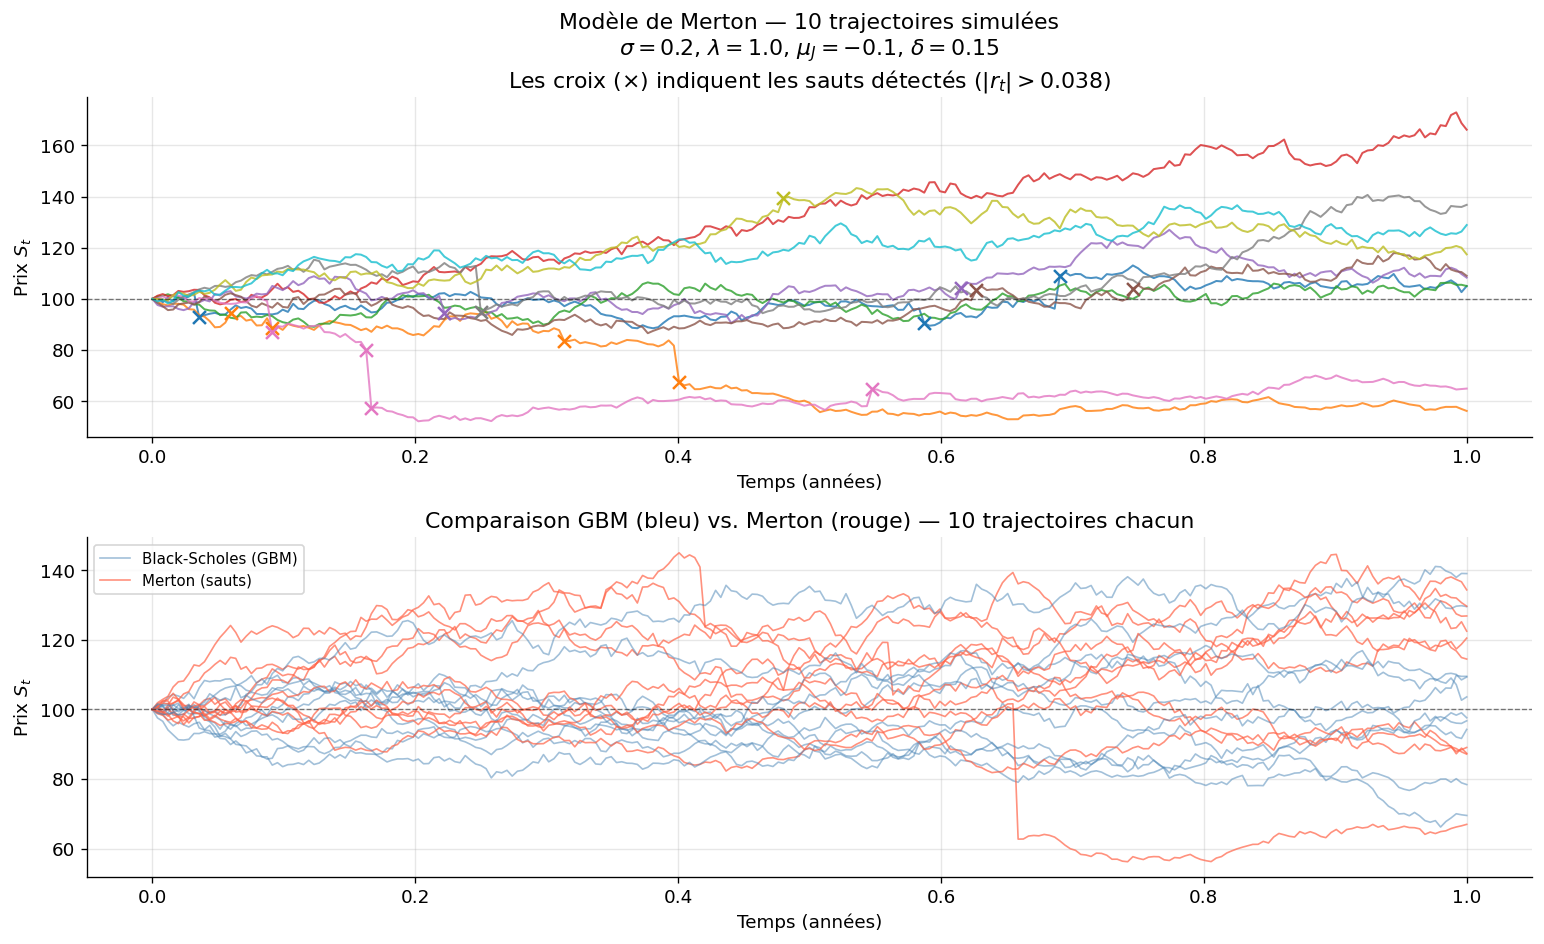

Figure sauvegardée : figures/E1_trajectoires.png


In [4]:
N_display = 10
time_grid = np.linspace(0, T, N_steps + 1)

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# ── Panneau supérieur : 10 trajectoires ─────────────────────────────────────
ax1 = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, N_display))

# Seuil de détection des sauts : log-rendement > 2.5 * sigma * sqrt(dt)
dt = T / N_steps
jump_threshold = 3.0 * sigma * np.sqrt(dt)

for idx in range(N_display):
    path = paths[idx]
    ax1.plot(time_grid, path, color=colors[idx], alpha=0.8, linewidth=1.2, label=f'Traj. {idx+1}')
    
    # Détection et marquage des sauts
    log_ret = np.log(path[1:] / path[:-1])
    jump_mask = np.abs(log_ret) > jump_threshold
    jump_times = time_grid[1:][jump_mask]
    jump_prices = path[1:][jump_mask]
    ax1.scatter(jump_times, jump_prices, color=colors[idx], s=60, zorder=5, marker='x')

ax1.axhline(S0, color='black', linestyle='--', linewidth=0.8, alpha=0.5, label='$S_0$')
ax1.set_xlabel('Temps (années)')
ax1.set_ylabel('Prix $S_t$')
ax1.set_title(
    f'Modèle de Merton — 10 trajectoires simulées\n'
    f'$\\sigma={sigma}$, $\\lambda={lambda_}$, $\\mu_J={mu_J}$, $\\delta={delta}$\n'
    f'Les croix (×) indiquent les sauts détectés ($|r_t| > {jump_threshold:.3f}$)'
)

# ── Panneau inférieur : comparaison Merton vs. GBM ──────────────────────────
ax2 = axes[1]

# Simulation d'un GBM pur pour comparaison
paths_gbm = simulate_merton_paths(
    S0=S0, mu=mu, sigma=sigma,
    lambda_=0.0, mu_J=mu_J, delta=delta,  # lambda=0 : pas de sauts
    T=T, N_steps=N_steps, N_paths=N_display, seed=SEED+1
)

paths_merton_display = simulate_merton_paths(
    S0=S0, mu=mu, sigma=sigma,
    lambda_=lambda_, mu_J=mu_J, delta=delta,
    T=T, N_steps=N_steps, N_paths=N_display, seed=SEED+2
)

for idx in range(N_display):
    if idx == 0:
        ax2.plot(time_grid, paths_gbm[idx], color='steelblue', alpha=0.5,
                 linewidth=1.0, label='Black-Scholes (GBM)')
        ax2.plot(time_grid, paths_merton_display[idx], color='tomato', alpha=0.7,
                 linewidth=1.0, label='Merton (sauts)')
    else:
        ax2.plot(time_grid, paths_gbm[idx], color='steelblue', alpha=0.5, linewidth=1.0)
        ax2.plot(time_grid, paths_merton_display[idx], color='tomato', alpha=0.7, linewidth=1.0)

ax2.axhline(S0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.set_xlabel('Temps (années)')
ax2.set_ylabel('Prix $S_t$')
ax2.set_title('Comparaison GBM (bleu) vs. Merton (rouge) — 10 trajectoires chacun')
ax2.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/E1_trajectoires.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/E1_trajectoires.png')

## 4. Histogramme des log-rendements

On trace l'histogramme des log-rendements journaliers sur l'ensemble des
$N_{\text{paths}} \times N_{\text{steps}}$ observations, et on le compare à la
densité gaussienne ajustée. La présence de sauts se traduit par des **queues épaisses**
(leptokurticité) et une **asymétrie négative** (skew).

Statistiques des log-rendements journaliers :
  N observations : 2,520,000
  Moyenne        : 0.000070
  Écart-type     : 0.016879
  Excès kurtosis : 142.6447  (>0 : queues épaisses)
  Skewness       : -6.2280  (<0 : asymétrie négative)


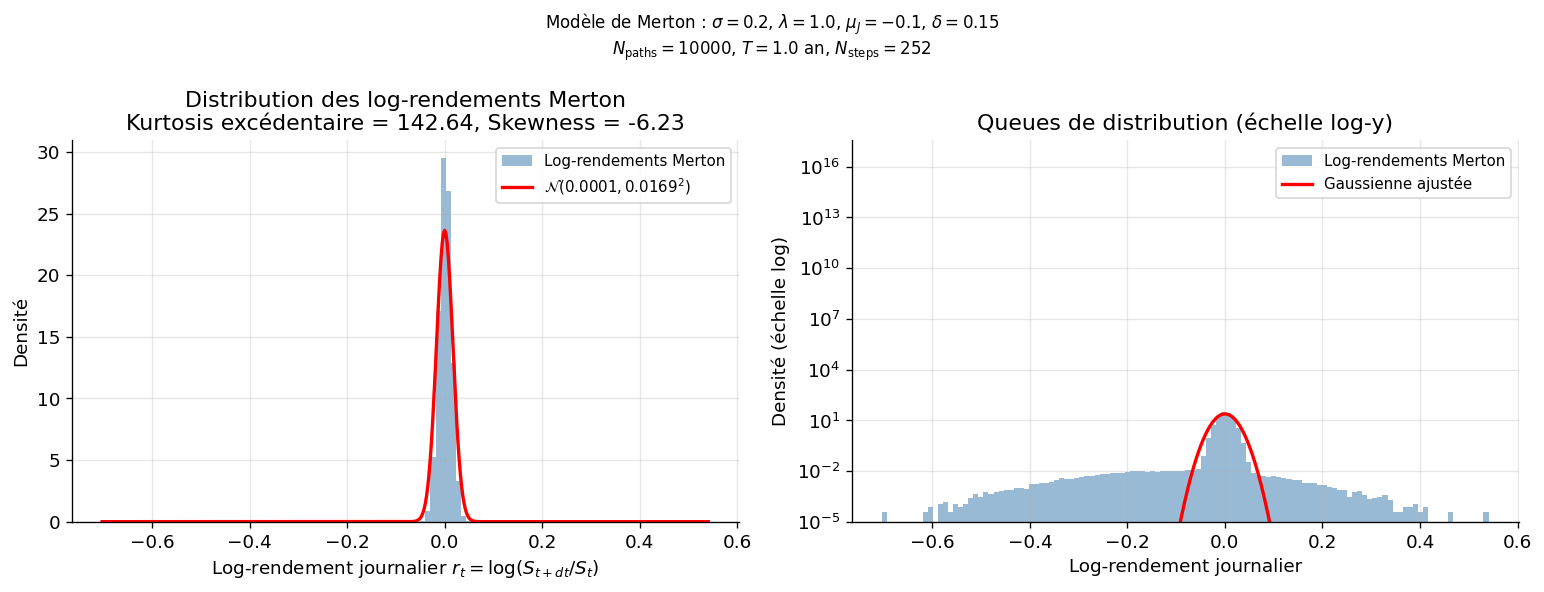

Figure sauvegardée : figures/E1_histogramme_rendements.png


In [5]:
# Calcul des log-rendements
rets = log_returns(paths).flatten()  # shape : (N_paths * N_steps,)

# Statistiques
mean_r  = rets.mean()
std_r   = rets.std()
kurt_r  = excess_kurtosis(rets)   # excess kurtosis
skew_r  = skewness(rets)

print('Statistiques des log-rendements journaliers :')
print(f'  N observations : {len(rets):,}')
print(f'  Moyenne        : {mean_r:.6f}')
print(f'  Écart-type     : {std_r:.6f}')
print(f'  Excès kurtosis : {kurt_r:.4f}  (>0 : queues épaisses)')
print(f'  Skewness       : {skew_r:.4f}  (<0 : asymétrie négative)')

# ── Figure ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme
ax = axes[0]
x_range = np.linspace(rets.min(), rets.max(), 500)
ax.hist(rets, bins=120, density=True, alpha=0.55, color='steelblue',
        label='Log-rendements Merton', edgecolor='none')
ax.plot(x_range, norm_pdf_vec(x_range, mean_r, std_r),
        'r-', linewidth=2, label=f'$\\mathcal{{N}}({mean_r:.4f}, {std_r:.4f}^2)$')
ax.set_xlabel('Log-rendement journalier $r_t = \\log(S_{t+dt}/S_t)$')
ax.set_ylabel('Densité')
ax.set_title(
    f'Distribution des log-rendements Merton\n'
    f'Kurtosis excédentaire = {kurt_r:.2f}, Skewness = {skew_r:.2f}'
)
ax.legend(fontsize=9)
ax.set_yscale('linear')

# Même chose en échelle log (pour voir les queues)
ax2 = axes[1]
ax2.hist(rets, bins=120, density=True, alpha=0.55, color='steelblue',
         label='Log-rendements Merton', edgecolor='none')
ax2.plot(x_range, norm_pdf_vec(x_range, mean_r, std_r),
         'r-', linewidth=2, label='Gaussienne ajustée')
ax2.set_xlabel('Log-rendement journalier')
ax2.set_ylabel('Densité (échelle log)')
ax2.set_title('Queues de distribution (échelle log-y)')
ax2.set_yscale('log')
ax2.set_ylim(bottom=1e-5)
ax2.legend(fontsize=9)

plt.suptitle(
    f'Modèle de Merton : $\\sigma={sigma}$, $\\lambda={lambda_}$, $\\mu_J={mu_J}$, $\\delta={delta}$\n'
    f'$N_{{\\text{{paths}}}}={N_paths}$, $T={T}$ an, $N_{{\\text{{steps}}}}={N_steps}$',
    fontsize=10
)
plt.tight_layout()
plt.savefig('../figures/E1_histogramme_rendements.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : figures/E1_histogramme_rendements.png')

## 5. Analyse de l'impact des paramètres de saut

On trace la distribution des log-rendements pour différentes valeurs de $\lambda$ afin
d'illustrer l'effet de la fréquence des sauts sur les propriétés statistiques.

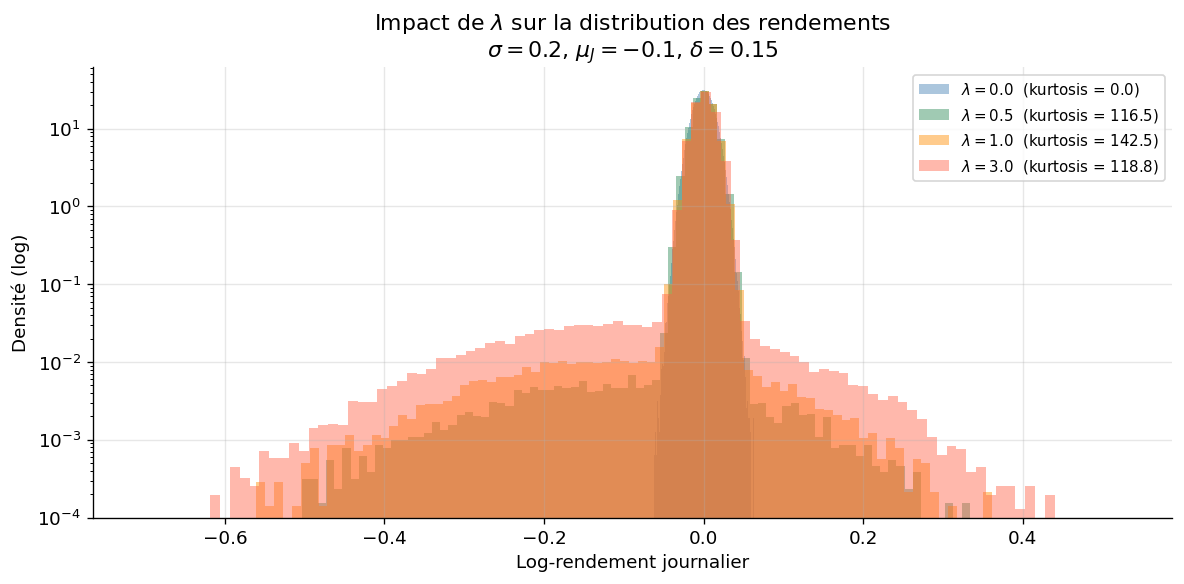

In [6]:
lambda_values = [0.0, 0.5, 1.0, 3.0]
colors_lambda = ['steelblue', 'seagreen', 'darkorange', 'tomato']

fig, ax = plt.subplots(figsize=(10, 5))

for lam, col in zip(lambda_values, colors_lambda):
    p = simulate_merton_paths(
        S0=S0, mu=mu, sigma=sigma,
        lambda_=lam, mu_J=mu_J, delta=delta,
        T=T, N_steps=N_steps, N_paths=5000, seed=SEED
    )
    r = log_returns(p).flatten()
    kurt_val = excess_kurtosis(r)
    ax.hist(r, bins=100, density=True, alpha=0.45, color=col,
            label=f'$\\lambda={lam}$  (kurtosis = {kurt_val:.1f})',
            edgecolor='none')

ax.set_yscale('log')
ax.set_ylim(bottom=1e-4)
ax.set_xlabel('Log-rendement journalier')
ax.set_ylabel('Densité (log)')
ax.set_title(
    f'Impact de $\\lambda$ sur la distribution des rendements\n'
    f'$\\sigma={sigma}$, $\\mu_J={mu_J}$, $\\delta={delta}$'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../figures/E1_impact_lambda.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Tableau de statistiques récapitulatives

In [7]:
import pandas as pd

rows = []
for lam in [0.0, 0.5, 1.0, 2.0, 3.0]:
    p = simulate_merton_paths(
        S0=S0, mu=mu, sigma=sigma,
        lambda_=lam, mu_J=mu_J, delta=delta,
        T=T, N_steps=N_steps, N_paths=N_paths, seed=SEED
    )
    r = log_returns(p).flatten()
    rows.append({
        'λ': lam,
        'Moyenne': f'{r.mean():.5f}',
        'Écart-type': f'{r.std():.5f}',
        'Skewness': f'{skewness(r):.3f}',
        'Kurtosis exc.': f'{excess_kurtosis(r):.3f}',
        'Min': f'{r.min():.4f}',
        'Max': f'{r.max():.4f}',
    })

df = pd.DataFrame(rows).set_index('λ')
print('Statistiques des log-rendements journaliers selon λ')
print(df.to_string())

Statistiques des log-rendements journaliers selon λ
      Moyenne Écart-type Skewness Kurtosis exc.      Min     Max
λ                                                               
0.0   0.00013    0.01260    0.000         0.004  -0.0640  0.0632
0.5   0.00008    0.01490   -4.565       114.887  -0.5925  0.6040
1.0   0.00007    0.01688   -6.228       142.645  -0.7023  0.5405
2.0  -0.00001    0.02045   -7.258       135.563  -0.6688  0.4460
3.0  -0.00006    0.02320   -7.251       119.315  -0.7591  0.5426


## Conclusion

L'expérience E1 montre que :

1. **Les trajectoires de Merton** présentent des sauts discontinus visibles, absents du GBM de Black-Scholes.
2. **La distribution des rendements** est leptokurtique (queues épaisses) et asymétrique (skew négatif pour $\mu_J < 0$), conformément aux faits stylisés des marchés financiers.
3. L'intensité $\lambda$ contrôle directement l'épaisseur des queues : plus $\lambda$ est grand, plus l'excès de kurtosis est élevé.

Ces propriétés motivent l'utilisation du modèle de Merton en lieu et place de Black-Scholes pour la valorisation des options.